# This Jupyter notebook file produces the subspace analysis results in the paper

In [1]:
import numpy as np
import scipy
import mat73
import sklearn
from utility_functions import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as Patches
from itertools import chain
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis,PCA
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as mticker
from contrastive import CPCA

plt.rcParams["axes.linewidth"] = 2
plt.rcParams["axes.edgecolor"] = 'k'
plt.rcParams['grid.alpha'] = 0

# Load the data and meta data
 Here we need to load the entire trials. So `data_type` should be "trials"

In [2]:
data_type='trials' # this could be 'trials', 'last4s', 'first4s'.
monkey='C' # monkey should be one of 'C', 'J' or 'M'
CE=63 # channel name. NOTE: this is not the channel number or the channel index

# load the grid layout of the monkey
grid=get_grid(monkey)
# load the spike channel number
spike_channel=get_channel(monkey,CE)
# load the location of the CE on the grid
loc_x,loc_y=get_CE_loc(grid,spike_channel)
# load the shunted electrodes for this monkey. This is the python index
shunted_electrodes=load_shunted_electrodes(monkey,spike_channel)
# finally, load the raw data
raw_data=load_ONF_data(data_type, monkey, CE)
# We only need the "learned" files.
raw_data=raw_data[raw_data['file_types']=='learned']

Optional: Visualize the data table. This may take some time.

In [3]:
raw_data

,file_num,file_types,num_success,num_failed,success_rate,spike_rate,HGA,target_types,velocity,position,trial_types
4,08012013002,learned,45.0,74.0,0.37815126050420167,[[[[37.78219587 34.83355969 21.30376545 11.654...,[[[[-1.2955235 0.19664705 -2.5070179 -1.402...,"[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, ...","[[[[-31.78944304 4.00952926], [-32.83597696 ...","[[[[-0.23667226 -1.26665779], [-0.96468212 -1....","[-1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0, -1.0, 1...."
9,08022013002,learned,49.0,41.0,0.5444444444444444,[[[[41.17127438 40.74463086 39.5816512 37.770...,[[[[-3.1443639 -2.5824733 -2.01486 -0.491...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...","[[[[-8.87993552 16.43822088], [-13.77009195 ...","[[[[0.93266359 1.0695934 ], [1.2017433 0.7525...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
10,08022013003,learned,44.0,78.0,0.36065573770491804,[[[[20.5403684 18.88004013 18.00324878 15.840...,[[[[-0.5619405 -2.0467007 -4.2300587 -3.569...,"[1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, ...","[[[[-27.28851931 -0.26926826], [-20.9618338 ...","[[[[-1.4466861 -1.29637257], [-1.64433306 -1....","[1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0,..."
11,08022013005,learned,69.0,53.0,0.5655737704918032,[[[[47.17476606 37.30643547 22.61452023 14.361...,[[[[ 0.3006306 -0.6947775 -2.6825457 -3.156...,"[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ...","[[[[-7.4602796 9.26700473], [-7.8776836 13....","[[[[-0.3664992 0.3430009], [-0.01786717 0.53...","[1.0, -1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0..."
12,08022013006,learned,64.0,62.0,0.5079365079365079,[[[[53.72926922 36.86659502 29.74394572 35.443...,[[[[-0.2623547 -1.1704111 -4.287936 -1.155...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[[[[-2.61273284 5.18588986], [-7.99927644 10....","[[[[1.5409294 1.15504654], [1.89976098 1.1750...","[1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, 1.0, 1.0..."
13,08022013007,learned,55.0,46.0,0.5445544554455446,[[[[27.07294839 24.16458878 29.56866572 22.560...,[[[[-1.7662884 -1.4304764 -3.873187 -3.405...,"[1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...","[[[[-28.63606972 -0.20180637], [-28.90020126 ...","[[[[-1.07144855 -1.21086296], [-1.78767669 -1....","[1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0,..."
14,08052013003,learned,53.0,21.0,0.7162162162162162,[[[[39.93872479 38.44074316 40.01919587 26.597...,[[[[-1.487525 -1.1627358 -1.1516471 -2.381...,"[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...","[[[[-10.69053104 16.20064816], [-6.63321708 1...","[[[[-0.60551747 1.07519505], [-0.1076792 1....","[1.0, 1.0, -1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,..."
15,08052013004,learned,50.0,58.0,0.46296296296296297,[[[[29.55811083 32.70981161 32.28349772 36.255...,[[[[-2.8955615 -5.5926695 -1.8910509 -2.749...,"[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ...","[[[[-27.39473095 5.73136214], [-28.59024065 ...","[[[[ 0.16738311 -0.10028641], [-0.45241397 -0....","[1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0, 1.0, 1.0,..."
16,08062013002,learned,67.0,57.0,0.5403225806451613,[[[[34.19925344 30.06997058 22.11687822 19.584...,[[[[-5.414543 -1.585173 -1.7933583 -2.783...,"[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, ...","[[[[-13.92819494 15.62767019], [-10.98904671 ...","[[[[0.5801101 1.61501267], [0.80652004 1.9643...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
17,08062013003,learned,51.0,77.0,0.3984375,[[[[11.00407817 12.29346175 13.36158531 8.665...,[[[[-1.9427422 -0.4643751 -0.35538906 -1.109...,"[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[[[[-17.70125178 6.40856018], [-16.95996664 ...","[[[[-0.14321223 -1.81598005], [-0.20736423 -1....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0,..."


# Pre-process the spike rate and HGA data

1. include only the successful trials.
2. remove shunted channels
3. remove NAN and empty channels
4. remove channels with low firing rate

In [4]:
# Here we concatenate all the successful trials together for every file.
spike_rate_all = list(chain.from_iterable([[d[0] for d in data] for data in raw_data['spike_rate'].to_list()]))
HGA_all = list(chain.from_iterable([[d[0] for d in data] for data in raw_data['HGA'].to_list()]))

# We concatenate the trial type
trial_types_all=np.concatenate(raw_data['trial_types'].to_list())

# We concatenate the target type
target_types_all=np.concatenate(raw_data['target_types'].to_list())

# We take out only the successful trials
spike_rate_successful=[a for a,t in zip(spike_rate_all,trial_types_all) if t==1 ]
HGA_successful=[a for a,t in zip(HGA_all,trial_types_all) if t==1]

# concatenate the signals
spike_rate_flat=np.concatenate(spike_rate_successful,axis=-1)
HGA_flat=np.concatenate(HGA_successful,axis=-1)
n_time=spike_rate_flat.shape[0]

# save the indices of the leftover electrodes
leftover_electrode_list=np.arange(0,spike_rate_flat.shape[0])

print(f"Before preprocessing, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")
# remove shunted electrodes
spike_rate_flat=np.delete(spike_rate_flat,shunted_electrodes,axis=0)
HGA_flat=np.delete(HGA_flat,shunted_electrodes,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,shunted_electrodes)
print(f"Removed the shunted electrodes, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")

# check NAN electrodes in the data
has_nan_spike_rate=np.sum(np.isnan(spike_rate_flat),axis=1)
has_nan_HGA=np.sum(np.isnan(HGA_flat),axis=1)
has_nan=np.where(has_nan_spike_rate+has_nan_HGA)

# remove the electrodes with NAN values
spike_rate_flat=np.delete(spike_rate_flat,has_nan,axis=0)
HGA_flat=np.delete(HGA_flat,has_nan,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,has_nan,axis=0)
print(f"Removed the electrodes with NAN values, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")

# check the electrodes with constant low spike rate
low_spike_rate=5 # spikes/s
has_low_spike_rate=np.sum(spike_rate_flat,axis=1)<n_time*low_spike_rate/20 # 20 Hz
has_low_spike_rate=np.where(has_low_spike_rate==spike_rate_flat.shape[-1])

# remove the electrodes with low spike rate
spike_rate_flat=np.delete(spike_rate_flat,has_low_spike_rate,axis=0)
HGA_flat=np.delete(HGA_flat,has_low_spike_rate,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,has_low_spike_rate)
print(f"Removed the electrodes with low spike rate, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")

# get the number of clean electrodes
n_clean_electrodes=len(leftover_electrode_list)
CE_index=np.where(leftover_electrode_list==spike_channel-1)[0]

Before preprocessing, signals have the shape (chan x (time x n_trials)): (96, 19272)
Removed the shunted electrodes, signals have the shape (chan x (time x n_trials)): (71, 19272)
Removed the electrodes with NAN values, signals have the shape (chan x (time x n_trials)): (63, 19272)
Removed the electrodes with low spike rate, signals have the shape (chan x (time x n_trials)): (63, 19272)


### Optional: check the correlation between CE neural siginals and velocities

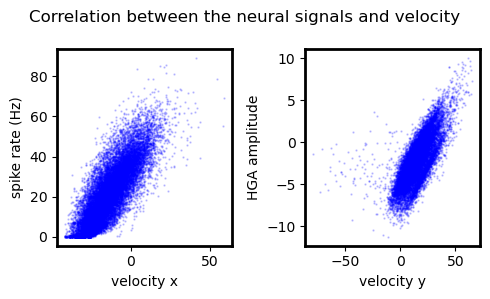

In [13]:
# get the velocity
velocity=list(chain.from_iterable(raw_data['velocity'].to_list()))
velocity=np.concatenate([v[0] for v, t in zip(velocity,trial_types_all) if t==1.0],axis=0)

# plot the correlation of velocity x and spike rate, velocity y and HGA
fig,ax=plt.subplots(1,2, figsize=(5,3))
ax[0].scatter(np.squeeze(velocity[:,0]),np.squeeze(spike_rate_flat[CE_index,:]),color='b',alpha=0.2,s=2,marker='.')
ax[0].set_xlabel('velocity x')
ax[0].set_ylabel('spike rate (Hz)')

ax[1].scatter(np.squeeze(velocity[:,1]),np.squeeze(HGA_flat[CE_index,:]),color='b',alpha=0.2,s=2,marker='.')
ax[1].set_xlabel('velocity y')
ax[1].set_ylabel('HGA amplitude')

# title
plt.suptitle("Correlation between the neural signals and velocity")
plt.tight_layout()
plt.show()

# Comparing the first factor to CE HGA and spike rate

In [6]:
# factor analysis on the mean centered, concatenated spike rate
n_factors=10

# zscore the spike rate data
spike_rate_zscore=scipy.stats.zscore(spike_rate_flat,axis=None)

# run factor analysis
fa=FactorAnalysis(n_components=n_factors,rotation='varimax')
factors=fa.fit_transform(spike_rate_zscore.T)
weights=fa.components_

# calculate the R between the factors and CE neural signals

R_factors_spike_rate=[]
R_factors_HGA=[]
for i in range(n_factors):
    # fit a linear regression model on factors and spike rate
    lr_factors_spike_rate=LinearRegression().fit(factors[:,:i+1],spike_rate_zscore[CE_index,:].T)
    # calculate the R2
    r2_factors_spike_rate=lr_factors_spike_rate.score(factors[:,:i+1],spike_rate_zscore[CE_index,:].T)
    R_factors_spike_rate.append(np.sqrt(r2_factors_spike_rate))


    # fit a linear regression model on factors and HGA
    lr_factors_HGA=LinearRegression().fit(factors[:,:i+1],HGA_flat[CE_index,:].T)
    # calculate the R2
    r2_factors_HGA=lr_factors_HGA.score(factors[:,:i+1],HGA_flat[CE_index,:].T)
    R_factors_HGA.append(np.sqrt(r2_factors_HGA))

plot R and the factor weights

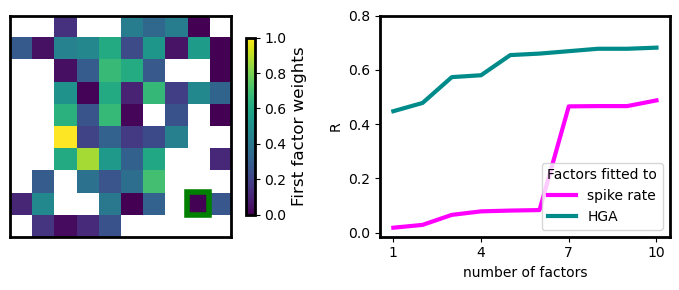

In [7]:
fig,ax = plt.subplots(1,2, figsize=(7,3))
im=plot_on_grid(ax[0],
             leftover_electrode_list,grid,
             np.abs(weights[0]),(loc_x,loc_y),
                cmap=mpb.cm.viridis
             )
im.set_clim(0,1)
cb=plt.colorbar(im,shrink=0.8)
cb.set_label('First factor weights',fontsize=12)

l1=ax[1].plot(np.arange(1,n_factors+1),R_factors_spike_rate,lw=3, label='spike rate',color='magenta')
l2=ax[1].plot(np.arange(1,n_factors+1),R_factors_HGA,lw=3,label='HGA',color='darkcyan')
ax[1].set_xticks(np.arange(1,n_factors+1,3))
ax[1].set_yticks(np.arange(0,1,0.2))
ax[1].set_xlabel('number of factors')
ax[1].set_ylabel('R')
ax[1].legend(title='Factors fitted to') 

plt.tight_layout()
plt.show()

### here we calculate the correlation between DWSS and HGA

In [8]:
# calculate the weighted grid for CE

weighted_grid=calculate_weighted_grid((loc_x,loc_y),power=2)
weighted_grid=get_the_weights(weighted_grid,
                             leftover_electrode_list,
                             grid.flatten())

# calculate the weighted sum of spike using the weights_grid
corr_HGA_DWSS=np.corrcoef(
                np.vstack([HGA_flat[CE_index],np.average(spike_rate_zscore,axis=0,weights=weighted_grid)]))[0,1]

# calculate the weighted grid for 20 random electrodes
n_random_pairs=20
random_pairs=draw_random_pairs(n_random_pairs,except_loc=(loc_x,loc_y))
random_weighted_grids=[get_the_weights(calculate_weighted_grid(r_pairs,power=2,emit_start_location=False),leftover_electrode_list,grid.flatten()) for r_pairs in random_pairs]

# calculate the weighted sum of spike using random weighted grids.
corr_HGA_random_DWSS=[np.corrcoef(np.vstack([HGA_flat[CE_index],np.average(spike_rate_zscore,axis=0,weights=r_grid)]))[0,1] for r_grid in random_weighted_grids]

# calculate the DWSS and HGA on non CE electrodes
# get the randomly selected electrodes
random_electrodes=np.random.choice(np.delete(leftover_electrode_list,np.where(leftover_electrode_list==spike_channel-1)),n_random_pairs,replace=False)+1
random_electrodes_loc=[np.where(grid==r) for r in random_electrodes]

# calculate the DWSS
random_weighted_grids=[get_the_weights(calculate_weighted_grid(r,power=2),leftover_electrode_list,grid.flatten()) for r in random_electrodes_loc]
# calculate the correlation between DWSS and HGA on those random electrodes
corr_random_HGA_DWSS=[np.corrcoef(np.squeeze(HGA_flat[np.where(leftover_electrode_list==random_electrodes[n]-1)[0]]), np.average(spike_rate_zscore,axis=0,weights=random_weighted_grids[n]))[0,1] for n in range(n_random_pairs)]

plotting

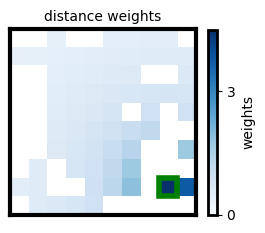

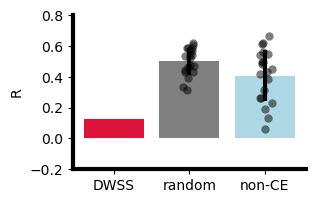

In [9]:
fig,ax=plt.subplots(1,1,figsize=(3,3))
im=plot_on_grid(ax,leftover_electrode_list,grid,np.sqrt(weighted_grid),(loc_x,loc_y),cmap=mpb.cm.Blues)
im.set_clim(0,0.003)
ax.set_title("distance weights",fontsize=10)
ax.spines[['left','bottom','top','right']].set_linewidth(3)
cb=fig.colorbar(im,shrink=0.8,ticks=[0,0.002],format=mticker.FixedFormatter(['0', '3']))
cb.set_label("weights",size=10)
cb.ax.set_yticklabels(['0', '3'])  # vertically oriented colorbar
cb.ax.tick_params(labelsize=10)


fig,ax=plt.subplots(1,1,figsize=(3,2))
ax.bar([0,1,2],
       np.abs(np.squeeze([
       corr_HGA_DWSS,
       np.mean(corr_HGA_random_DWSS),
       np.mean(corr_random_HGA_DWSS)]))
        ,color=['crimson','grey',"lightblue"],yerr=(0,np.std(corr_HGA_random_DWSS),np.std(corr_random_HGA_DWSS)),error_kw=dict(lw=3))
# plot the raw data
x = np.random.normal(1, 0.05, size=len(corr_HGA_random_DWSS))  # Jitter
ax.scatter(x, np.array(corr_HGA_random_DWSS), color='k', alpha=0.5, edgecolor='black', linewidth=0)
x = np.random.normal(2, 0.05, size=len(corr_random_HGA_DWSS))  # Jitter
ax.scatter(x, np.array(corr_random_HGA_DWSS), color='k', alpha=0.5, edgecolor='black', linewidth=0)

ax.set_xticks([0,1,2],["DWSS","random","non-CE"],rotation=0,fontsize=10)

ax.set_ylabel("R",fontsize=10)
ax.set_ylim(-0.2,0.8)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_linewidth(3)

plt.show()


# PCA and cPCA analysis on the correlation and subspace angles
1. define SP+ and HG+ NAS
2. perform PCA on the data separately
3. perform cPCA on the data separately
4. calculate the angles between them

In [10]:
# calculate the CE spike rate and HGA
CE_spike_rate=StandardScaler().fit_transform(spike_rate_zscore[CE_index].T)
CE_HGA=StandardScaler().fit_transform(HGA_flat[CE_index].T)

# calculated the sp+ and hg+ indices
NAS=np.squeeze(np.arctan2(CE_HGA, CE_spike_rate)*180/np.pi)
sp_ind=(NAS>=-15)&(NAS<=15)
hg_ind=(NAS>=75)&(NAS<=105)

Quick check of the dimensionality of the two data

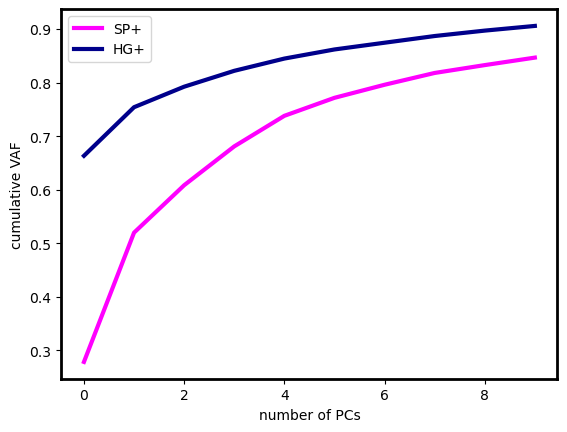

In [11]:
n_PCs=10
pca=PCA(n_components=n_PCs)
plt.figure()
plt.plot(np.cumsum(pca.fit(spike_rate_zscore[:,sp_ind].T).explained_variance_ratio_),lw=3,color='magenta')
plt.plot(np.cumsum(pca.fit(spike_rate_zscore[:,hg_ind].T).explained_variance_ratio_),lw=3,color='darkblue')
plt.ylabel("cumulative VAF")
plt.xlabel("number of PCs")
plt.legend(['SP+','HG+'])

In [12]:
# first we need to fine the best alpha for cPCA
cpca=CPCA(n_components=n_PCs,standardize=False)

# specify the range the step for the alphas to try
n_alphas=15
max_log_alpha=2

# prepare the data
sp_data=scipy.stats.zscore(spike_rate_zscore[:,sp_ind],axis=None)
hg_data=scipy.stats.zscore(spike_rate_zscore[:,hg_ind],axis=None)

# Use the plots to determin the best alpha
projected_fg,best_alphas=cpca.fit_transform(hg_data.T,
                                            sp_data.T,
                                            n_alphas=n_alphas,  max_log_alpha=max_log_alpha, alpha_selection='all',return_alphas=True)
projected_bg=cpca.transform(sp_data.T,n_alphas=n_alphas,  max_log_alpha=max_log_alpha, alpha_selection='all')

 - Plotting the background and foreground data with different alpha
- The peak of the ratio of variances in the second plot is where the best alpha value is

The best alpha value for this dataset it: 1.9306977288832496


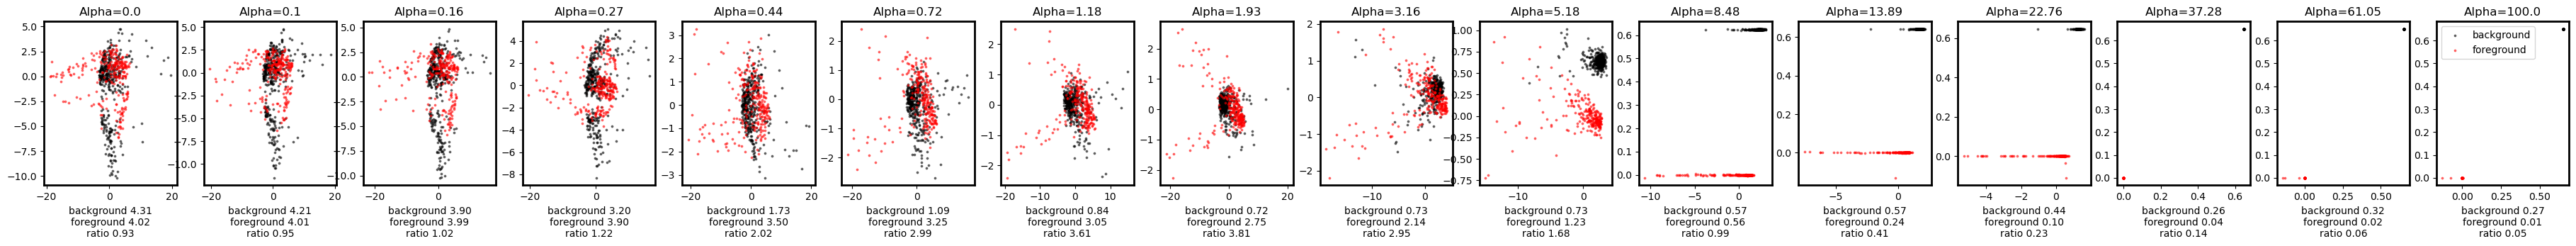

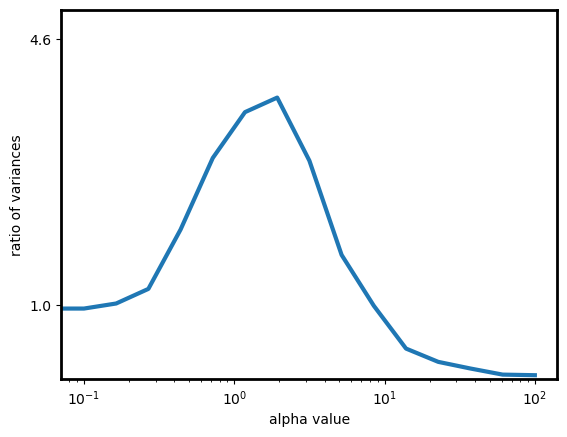

In [13]:
plt.figure(figsize=[3*n_alphas+1,3])
subsample=0.2 # only plot number of subsample x data  
all_ratio=[]
for j, pack in enumerate(zip(projected_fg,projected_bg)):
    # retrieve and subsample the background and foreground data
    fg,bg=pack
    subsample_bg=np.random.choice(len(bg),int(len(bg)*subsample),replace=False)
    subsample_fg=np.random.choice(len(fg),int(len(fg)*subsample),replace=False)
    
    # calculate the variance
    fg_variance=np.var(fg)
    bg_variance=np.var(bg)
    
    plt.subplot(1,n_alphas+1,j+1)
    plt.scatter(bg[subsample_bg,0],bg[subsample_bg,1], color='k', alpha=0.5, label='background',s=3)
    plt.scatter(fg[subsample_fg,0],fg[subsample_fg,1], color='r', alpha=0.5, label='foreground',s=3)
    plt.title('Alpha='+str(np.round(best_alphas[j],2)))
    plt.xlabel(f"background {bg_variance:0.2f}\nforeground {fg_variance:0.2f}\nratio {fg_variance/bg_variance:0.2f}")
    all_ratio.append(fg_variance/bg_variance)
plt.legend()

# plot the variance ratios for each alpha we selected
plt.figure()
plt.plot(best_alphas,all_ratio,lw=3)
plt.xscale("log")
plt.yticks(np.linspace(1,19,6))
plt.xlabel('alpha value')
plt.ylabel('ratio of variances')
plt.ylim(0,5)

print(f"The best alpha value for this dataset it: {best_alphas[np.argmax(all_ratio)]}")
plt.show()

## Now we are using the best alphao to produce the cPCs and correlate them with CE spike rate and CE HGA


In [35]:
alpha_selected=best_alphas[np.argmax(all_ratio)]

######################## fg: SP+, bg: HG+ ################################
fg_cov,bg_cov=get_cov(sp_data.T,hg_data.T)
v_top_SP=get_cpca_loadings(fg_cov,bg_cov,alpha_selected,n_PCs)

projected_bg_SP=hg_data.T @ v_top_SP
projected_fg_SP=sp_data.T @ v_top_SP

# fit the unique component one by one and see which component(s) contribute the most
cumsum_R2_SP_CPCA_FR=[]
cumsum_R2_SP_CPCA_HG=[]
for i in range(n_PCs):
    R2=(LinearRegression(fit_intercept=False)
        .fit(spike_rate_zscore.T@v_top_SP[:,:i+1],np.squeeze(spike_rate_zscore[CE_index]))
        .score(spike_rate_zscore.T@v_top_SP[:,:i+1],np.squeeze(spike_rate_zscore[CE_index])))
    cumsum_R2_SP_CPCA_FR.append(np.maximum(R2,0))

    R2=(LinearRegression(fit_intercept=False)
        .fit(spike_rate_zscore.T@v_top_SP[:,:i+1],np.squeeze(HGA_flat[CE_index]))
        .score(spike_rate_zscore.T@v_top_SP[:,:i+1],np.squeeze(HGA_flat[CE_index])))
    cumsum_R2_SP_CPCA_HG.append(np.maximum(R2,0))


######################### fg: SP+, bg: HG+ ################################
fg_cov,bg_cov=get_cov(hg_data.T,sp_data.T)
v_top_HG=get_cpca_loadings(fg_cov,bg_cov,alpha_selected,n_PCs)

projected_bg_HG=sp_data.T @ v_top_HG
projected_fg_HG=hg_data.T @ v_top_HG

# fit the unique component one by one and see which component(s) contribute the most
cumsum_R2_HG_CPCA_FR=[]
cumsum_R2_HG_CPCA_HG=[]
for i in range(n_PCs):
    R2=(LinearRegression(fit_intercept=False)
        .fit(spike_rate_zscore.T@v_top_HG[:,:i+1],np.squeeze(spike_rate_zscore[CE_index,:]))
        .score(spike_rate_zscore.T@v_top_HG[:,:i+1],np.squeeze(spike_rate_zscore[CE_index,:])))
    cumsum_R2_HG_CPCA_FR.append(np.maximum(R2,0))

    R2=(LinearRegression(fit_intercept=False)
        .fit(spike_rate_zscore.T@v_top_HG[:,:i+1],np.squeeze(HGA_flat[CE_index,:]))
        .score(spike_rate_zscore.T@v_top_HG[:,:i+1],np.squeeze(HGA_flat[CE_index,:])))
    cumsum_R2_HG_CPCA_HG.append(np.maximum(R2,0))

Now we perform PCA on SP+ data and HG+ data separately

In [36]:
# same analysis using PCA (this equals to fg with alpha=0)
pca_projection_HG=PCA(n_PCs).fit_transform(hg_data.T)
pca_projection_SP=PCA(n_PCs).fit_transform(sp_data.T)
pca_loading_HG=PCA(n_PCs).fit(hg_data.T).components_.T
pca_loading_SP=PCA(n_PCs).fit(sp_data.T).components_.T
shuffle_pca_loading_HG=np.copy(pca_loading_HG)
shuffle_pca_loading_SP=np.copy(pca_loading_SP)
np.random.shuffle(shuffle_pca_loading_HG)
np.random.shuffle(shuffle_pca_loading_SP)


Prepare the shuffled dataset as control

In [37]:
sp_fr_shuffle = np.copy(sp_data)
np.random.shuffle(sp_fr_shuffle)
hg_fr_shuffle = np.copy(hg_data)
np.random.shuffle(hg_fr_shuffle)
fg_cov_shuffle,bg_cov_shuffle=get_cov(sp_fr_shuffle.T,hg_fr_shuffle.T)
v_top_SP_shuffle=get_cpca_loadings(fg_cov_shuffle,bg_cov_shuffle,alpha_selected,n_PCs)

np.random.shuffle(sp_fr_shuffle)
np.random.shuffle(hg_fr_shuffle)
bg_cov_shuffle,fg_cov_shuffle=get_cov(sp_fr_shuffle.T,hg_fr_shuffle.T)
v_top_HG_shuffle=get_cpca_loadings(fg_cov_shuffle,bg_cov_shuffle,alpha_selected,n_PCs)

Calculate the subspace angles between different PCs and cPCs

In [38]:
subspace_angles_cPCs=scipy.linalg.subspace_angles(v_top_HG, v_top_SP)
subspace_angles_cPCs_shuffle=scipy.linalg.subspace_angles(v_top_HG_shuffle, v_top_SP_shuffle)

subspace_angles_PCs=scipy.linalg.subspace_angles(pca_loading_HG, pca_loading_SP)
subspace_angles_PCs_shuffle=scipy.linalg.subspace_angles(shuffle_pca_loading_HG, shuffle_pca_loading_SP)

subspace_angles_cPCA_PCA_HG=scipy.linalg.subspace_angles(v_top_HG, pca_loading_HG)
subspace_angles_cPCA_PCA_SP=scipy.linalg.subspace_angles(v_top_SP, pca_loading_SP)
subspace_angles_shuffle_cPCA_PCA_HG=scipy.linalg.subspace_angles(v_top_HG_shuffle, shuffle_pca_loading_HG)
subspace_angles_shuffle_cPCA_PCA_SP=scipy.linalg.subspace_angles(v_top_SP_shuffle, shuffle_pca_loading_SP)

Here we demostrated the correlation (R) between the spike rate, HGA and SP+/HG+ cPCs

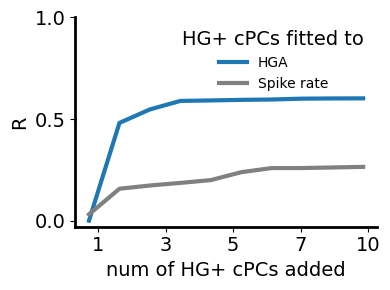

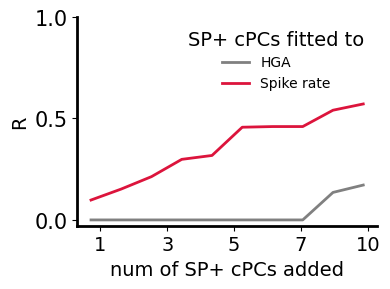

In [39]:
fig,ax=plt.subplots(1,1,figsize=(4,3))
ax.plot(np.linspace(1,3*n_PCs,n_PCs),np.sqrt(cumsum_R2_HG_CPCA_HG),color='tab:blue',lw=3)
ax.plot(np.linspace(1,3*n_PCs,n_PCs),np.sqrt(cumsum_R2_HG_CPCA_FR),color='grey',lw=3)

ax.set_xticks(np.linspace(2,3*n_PCs+0.5,5),np.int16(np.linspace(1,n_PCs,5)),fontsize=14)
ax.set_yticks(np.linspace(0,1,3),np.linspace(0,1,3),fontsize=14)
ax.legend(["HGA","Spike rate"],frameon=False,loc="upper right",title="HG+ cPCs fitted to",title_fontsize=14,fontsize=10)
ax.set_xlabel("num of HG+ cPCs added",fontsize=14)
ax.set_ylabel("R",fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


fig,ax=plt.subplots(1,1,figsize=(4,3))
ax.plot(np.linspace(1,3*n_PCs,n_PCs),np.sqrt(cumsum_R2_SP_CPCA_HG),color='grey',lw=2)
ax.plot(np.linspace(1,3*n_PCs,n_PCs),np.sqrt(cumsum_R2_SP_CPCA_FR),color='crimson',lw=2)

ax.set_xticks(np.linspace(2,3*n_PCs+0.5,5),np.int16(np.linspace(1,n_PCs,5)),fontsize=14)
ax.set_yticks(np.linspace(0,1,3),np.linspace(0,1,3),fontsize=15)
ax.legend(["HGA","Spike rate"],frameon=False,loc="best",title="SP+ cPCs fitted to",title_fontsize=14,fontsize=10)
ax.set_xlabel("num of SP+ cPCs added",fontsize=14)
ax.set_ylabel("R",fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

plt.show()

Here we demonstrate the cPCA weights and that HG+ cPCs have more activation in other electrodes, compared to SP+ cPCs

In [ ]:
### another figure: plot the first cPC on the grid
first_cPC_weights_SP=np.abs(v_top_SP[:,0])/np.abs(v_top_SP[:,0]).max()
first_cPC_weights_HG=np.abs(v_top_HG[:,0])/np.abs(v_top_HG[:,0]).max()

fig,ax=plt.subplots(1,2,layout='constrained',figsize=(7,4))
im1=plot_on_grid(ax[0],leftover_electrode_list,grid,first_cPC_weights_SP,(loc_x,loc_y),
                      cmap=mpb.cm.viridis,show_chan_indx=False,CE_color='r')
im2=plot_on_grid(ax[1],leftover_electrode_list,grid,first_cPC_weights_HG,(loc_x,loc_y),
                      cmap=mpb.cm.viridis,show_chan_indx=False,CE_color='r')
#clim_min=np.min([v_top_SP[:,0],v_top_HG[:,0]])
clim=np.max([first_cPC_weights_SP,first_cPC_weights_HG])
#clim=np.maximum(clim_max,np.abs(clim_min))
im1.set_clim([0,clim-0.3])
im2.set_clim([0,clim-0.1])
cb=fig.colorbar(im2, ax=ax[:], location='right',shrink=0.6,pad=0.1)
cb.set_label("cPC weights",fontsize=12)
cb.ax.tick_params(labelsize=12)
ax[0].set_title("SP+ 1st cPC",fontsize=12)
ax[1].set_title("HG+ 1st cPC",fontsize=12)

### some quantification: save the first cPC weights
fig,ax=plt.subplots(1,1,figsize=(4,4))
ax.violinplot([first_cPC_weights_SP,first_cPC_weights_HG])
plt.show()